In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;
using JJDFTX: kinetic_energy

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
rgb(x, y, z) = [x, y, z] ./ 255

rgb (generic function with 1 method)

In [4]:
lattice_vectors = loadlattice("./LDA_No_Correlation/BN22BC.doping-1.out")
Vol = unit_cell_volume(lattice_vectors)/bohrtoangstrom^3

3032.707840704

In [5]:
x_n_lda_cnone = Float64[]
x_vscloc_lda_cnone = Float64[]
splits_lda_cnone = Float64[]

dir = "./LDA_No_Correlation/"

for i in 2:40
    println("Iteration: $i"); flush(stdout)
    charge = round(-1+(i-1)/40, digits=3)
    
    filename_vscloc_up = dir*"./BN22BC-$(charge).Vscloc_up"
    
    filename_vscloc_dn = dir*"./BN22BC-$(charge).Vscloc_dn"
        
    filename_nup = dir*"./BN22BC-$(charge).n_up"
    
    filename_ndn = dir*"./BN22BC-$(charge).n_dn"

    Vscloc_up = np.fromfile(filename_vscloc_up)
    Vscloc_dn = np.fromfile(filename_vscloc_dn)
    
    n_up = np.fromfile(filename_nup)
    n_dn = np.fromfile(filename_ndn)
    
    # The seventeenth band is the defect band, but JDFTX reports with zero based indexing
    # The index j labels the k point- here we just use the gamma point

    wfns_up = [(abs.(np.fromfile(dir*"BN22BC-$charge.wfns_$(j)_16.rs", dtype=np.complex))).^2 for j in 0:0]
    wfns_dn = [(abs.(np.fromfile(dir*"BN22BC-$charge.wfns_$(j)_16.rs", dtype=np.complex))).^2 for j in 0:0]
    
    vscloc_diff_up = sum([sum(Vscloc_up .* wfn_up) for wfn_up in wfns_up])
    vscloc_diff_dn = sum([sum(Vscloc_dn .*wfn_dn) for wfn_dn in wfns_dn])
    
    n_diff_up = sum([sum(n_up.^(1/3).*wfn_up) for wfn_up in wfns_up])
    n_diff_dn = sum([sum(n_dn.^(1/3).*wfn_dn) for wfn_dn in wfns_dn])
    
    # The wavefunctions are given per volume 
    
    push!(x_n_lda_cnone, abs(n_diff_up - n_diff_dn)*Vol/length(n_up)*1/eV)

    push!(x_vscloc_lda_cnone, abs(vscloc_diff_up - vscloc_diff_dn)*1/eV)
    
    filename_eigenvals = dir*"./BN22BC-$(charge).eigenvals"
    
    data = JJDFTX.bandstruct_properties(filename_eigenvals, 32, 19, spin=2);

    push!(splits_lda_cnone, abs(mean(data[2][17]) - mean(data[1][17])))
end

Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40


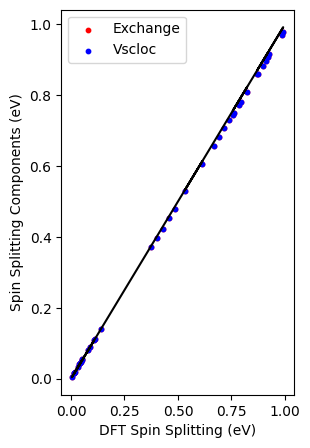

PyObject Text(24.000000000000007, 0.5, 'Spin Splitting Components (eV)')

In [6]:
figure(figsize=(3, 5))

# The factor of 1.26 is 2^(1/3)
scatter(splits_lda_cnone, x_n_lda_cnone.*(1.26)*((3/pi)^(1/3)), label="Exchange", color="red", s=10)
scatter(splits_lda_cnone, x_vscloc_lda_cnone, label="Vscloc", color="blue", s=10)
plot(splits_lda_cnone, splits_lda_cnone, color="black")
legend()
xlabel("DFT Spin Splitting (eV)")
ylabel("Spin Splitting Components (eV)")

In [7]:
x_n_lda = Float64[]
x_vscloc_lda = Float64[]
splits_lda = Float64[]
dir = "./LDA/"

for i in 2:40
    #i == 34 && continue
    println("Iteration: $i"); flush(stdout)
    charge = round(-1+(i-1)/40, digits=3)
    
    filename_vscloc_up = dir*"./BN22BC-$(charge).Vscloc_up"
    
    filename_vscloc_dn = dir*"./BN22BC-$(charge).Vscloc_dn"
        
    filename_nup = dir*"./BN22BC-$(charge).n_up"
    
    filename_ndn = dir*"./BN22BC-$(charge).n_dn"

    Vscloc_up = np.fromfile(filename_vscloc_up)
    Vscloc_dn = np.fromfile(filename_vscloc_dn)
    
    n_up = np.fromfile(filename_nup)
    n_dn = np.fromfile(filename_ndn)

    wfns_up = [(abs.(np.fromfile(dir*"BN22BC-$charge.wfns_$(j)_16.rs", dtype=np.complex))).^2 for j in 0:0]
    wfns_dn = [(abs.(np.fromfile(dir*"BN22BC-$charge.wfns_$(j)_16.rs", dtype=np.complex))).^2 for j in 0:0]
    
    vscloc_diff_up = sum([sum(Vscloc_up .* wfn_up) for wfn_up in wfns_up])
    vscloc_diff_dn = sum([sum(Vscloc_dn .*wfn_dn) for wfn_dn in wfns_dn])
    
    n_diff_up = sum([sum(n_up.^(1/3).*wfn_up) for wfn_up in wfns_up])
    n_diff_dn = sum([sum(n_dn.^(1/3).*wfn_dn) for wfn_dn in wfns_dn])
    
    push!(x_n_lda, abs(n_diff_up - n_diff_dn)*Vol/length(n_up)*1/eV)

    push!(x_vscloc_lda, abs(vscloc_diff_up - vscloc_diff_dn)*1/eV)
    
    filename_eigenvals = dir*"./BN22BC-$(charge).eigenvals"
    
    data = JJDFTX.bandstruct_properties(filename_eigenvals, 32, 19, spin=2);

    push!(splits_lda, abs(mean(data[2][17]) - mean(data[1][17])))
end

Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40


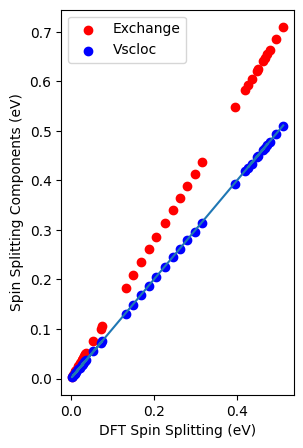

PyObject Text(24.000000000000007, 0.5, 'Spin Splitting Components (eV)')

In [8]:
figure(figsize=(3, 5))
#Factor of 1.26 is 2^(1/3)
scatter(splits_lda, x_n_lda.*(1.26)*((3/pi)^(1/3)), label="Exchange", color="red")
scatter(splits_lda, x_vscloc_lda, label="Vscloc", color="blue")
plot(splits_lda, splits_lda)
legend()
xlabel("DFT Spin Splitting (eV)")
ylabel("Spin Splitting Components (eV)")

In [11]:
x_n_pbe = Float64[]
x_vscloc_pbe = Float64[]
splits_pbe = Float64[]
dir = "./"

for i in 2:41
    #i == 34 && continue
    println("Iteration: $i"); flush(stdout)
    charge = round(-1+(i-1)/40, digits=3)
    
    filename_vscloc_up = dir*"./BN22BC-$(charge).Vscloc_up"
    
    filename_vscloc_dn = dir*"./BN22BC-$(charge).Vscloc_dn"
        
    filename_nup = dir*"./BN22BC-$(charge).n_up"
    
    filename_ndn = dir*"./BN22BC-$(charge).n_dn"

    Vscloc_up = np.fromfile(filename_vscloc_up)
    Vscloc_dn = np.fromfile(filename_vscloc_dn)
    
    n_up = np.fromfile(filename_nup)
    n_dn = np.fromfile(filename_ndn)

    wfns_up = [(abs.(np.fromfile(dir*"BN22BC-$charge.wfns_$(j)_16.rs", dtype=np.complex))).^2 for j in 0:0]
    wfns_dn = [(abs.(np.fromfile(dir*"BN22BC-$charge.wfns_$(j)_16.rs", dtype=np.complex))).^2 for j in 0:0]
    
    vscloc_diff_up = sum([sum(Vscloc_up .* wfn_up) for wfn_up in wfns_up])
    vscloc_diff_dn = sum([sum(Vscloc_dn .*wfn_dn) for wfn_dn in wfns_dn])
    
    n_diff_up = sum([sum(n_up.^(1/3).*wfn_up) for wfn_up in wfns_up])
    n_diff_dn = sum([sum(n_dn.^(1/3).*wfn_dn) for wfn_dn in wfns_dn])
    
    push!(x_n_pbe, abs(n_diff_up - n_diff_dn)*Vol/length(n_up)*1/eV)

    push!(x_vscloc_pbe, abs(vscloc_diff_up - vscloc_diff_dn)*1/eV)
    
    filename_eigenvals = dir*"./BN22BC-$(charge).eigenvals"
    
    band_data = np.reshape(np.fromfile(filename_eigenvals), (38, 32))
    band_data_up = band_data[1:19, :]
    band_data_dn = band_data[20:end, :]
    
    data = JJDFTX.bandstruct_properties(filename_eigenvals, 32, 19, spin=2);
    push!(splits_pbe, abs(band_data_up[1, 17] - band_data_dn[1, 17])*1/eV)
    #push!(splits, abs(mean(data[2][17]) - mean(data[1][17])))
end

Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41


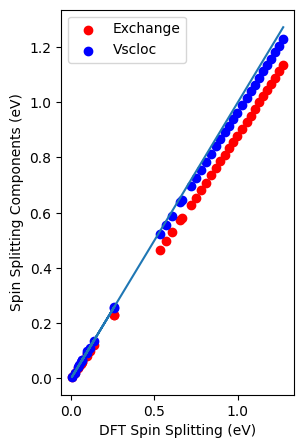

PyObject Text(24.000000000000007, 0.5, 'Spin Splitting Components (eV)')

In [12]:
figure(figsize=(3, 5))
scatter(splits_pbe, x_n_pbe*(1.26)*((3/pi)^(1/3)), label="Exchange", color="red")
scatter(splits_pbe, x_vscloc_pbe, label="Vscloc", color="blue")
plot(splits_pbe, splits_pbe)
legend()
xlabel("DFT Spin Splitting (eV)")
ylabel("Spin Splitting Components (eV)")

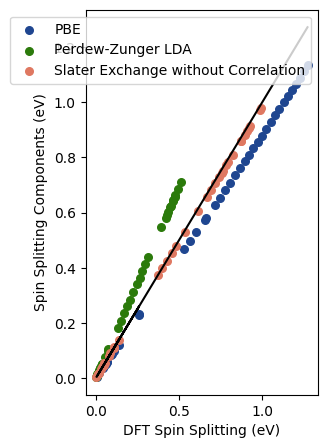

PyObject Text(48.2916666666667, 0.5, 'Spin Splitting Components (eV)')

In [13]:
dot_size = 30
pbe_color = rgb(31, 70, 144)
lda_color = rgb(43, 122, 11)
lda_cnone_color = rgb(223, 120, 97)
figure(figsize=(3, 5))
scatter(splits_pbe, x_n_pbe.*(1.26)*((3/pi)^(1/3)), label="PBE", color=pbe_color, s=dot_size)
scatter(splits_lda, x_n_lda.*(1.26)*((3/pi)^(1/3)), label="Perdew-Zunger LDA", color=lda_color, s=dot_size)
scatter(splits_lda_cnone, x_n_lda_cnone.*(1.26)*((3/pi)^(1/3)), label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)
plot(splits_pbe, splits_pbe, color="black")
legend()
xlabel("DFT Spin Splitting (eV)")
ylabel("Spin Splitting Components (eV)")

In [20]:
open("Exchange_Model.txt", "w") do io 
    write(io, "splits_lda_cnone (eV), x_n_lda_cnone (eV), splits_lda_(eV), x_n_lda(eV), splits_pbe (eV), x_n_pbe (eV)\n" )
    for line in zip(splits_lda_cnone, x_n_lda_cnone.*(1.26)*((3/pi)^(1/3)), splits_lda, x_n_lda.*(1.26)*((3/pi)^(1/3)), splits_pbe, x_n_pbe.*(1.26)*((3/pi)^(1/3)))
        write(io, "$(line[1]), $(line[2]), $(line[3]), $(line[4]), $(line[5]), $(line[6]) \n" )
    end
end

In [23]:
splits_lda_cnone, x_n_lda_cnone, splits_lda, x_n_lda, splits_pbe, x_n_pbe = [col for col in eachcol(readdlm("Exchange_Model.txt", ',')[2:end, :])];

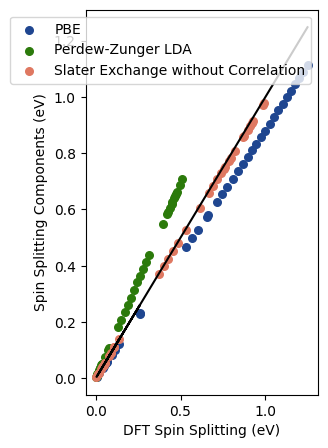

PyObject Text(48.2916666666667, 0.5, 'Spin Splitting Components (eV)')

In [24]:
dot_size = 30
pbe_color = rgb(31, 70, 144)
lda_color = rgb(43, 122, 11)
lda_cnone_color = rgb(223, 120, 97)
figure(figsize=(3, 5))
scatter(splits_pbe, x_n_pbe, label="PBE", color=pbe_color, s=dot_size)
scatter(splits_lda, x_n_lda, label="Perdew-Zunger LDA", color=lda_color, s=dot_size)
scatter(splits_lda_cnone, x_n_lda_cnone, label="Slater Exchange without Correlation", color=lda_cnone_color, s=dot_size)
plot(splits_pbe, splits_pbe, color="black")
legend()
xlabel("DFT Spin Splitting (eV)")
ylabel("Spin Splitting Components (eV)")

In [4]:
2^(1/3)

1.2599210498948732